<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [331]:
#Importation de la librairie Pandas
import pandas as pd

In [332]:
#Importation de la librairie plotly express
import plotly.express as px

In [333]:
##importation des autres librairies 
import numpy as np 
import missingno as msno 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns 

In [334]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium
#print(df.columns)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [335]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")

C:\Users\julie\.anaconda\Lib\site-packages\openpyxl\worksheet\_read_only.py:79: UserWarning:

Unknown extension is not supported and will be removed

C:\Users\julie\.anaconda\Lib\site-packages\openpyxl\worksheet\_read_only.py:79: UserWarning:

Unknown extension is not supported and will be removed

C:\Users\julie\.anaconda\Lib\site-packages\openpyxl\worksheet\_read_only.py:79: UserWarning:

Unknown extension is not supported and will be removed



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [336]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [337]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


In [338]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [339]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
df_erp[df_erp['product_id'].duplicated(keep=False)]
##pas de doublons

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price


In [340]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
print(df_erp['stock_status'].unique())
#df_erp['stock_status'] est de type object donc je la transforme en numérique à l'aide d'un mapping pour étudier les corrélations
mapping={'instock':1, 'outofstock':0}
df_erp['stock_status_num']= df_erp['stock_status'].map(mapping)
df_erp.corr(numeric_only=True)
#la colonne stock_status (transformée en numérique) n'a qu'une corrélation faible a modérée avec 'onsale_web' (0.36) et 'stock_quantity' (0.35)

['instock' 'outofstock']


,product_id,onsale_web,price,stock_quantity,purchase_price,stock_status_num
product_id,1.000000,-0.367579,0.118481,-0.148333,0.112399,0.075138
onsale_web,-0.367579,1.000000,0.041038,0.203830,0.022967,0.362141
price,0.118481,0.041038,1.000000,-0.086305,0.967573,0.000753
stock_quantity,-0.148333,0.203830,-0.086305,1.000000,-0.012056,0.350325
purchase_price,0.112399,0.022967,0.967573,-0.012056,1.000000,-0.005164
stock_status_num,0.075138,0.362141,0.000753,0.350325,-0.005164,1.000000


In [341]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp['stock_status_2']= np.where(df_erp['stock_quantity'] == 0, 'outofstock', 'instock')

In [342]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
comparaison= df_erp["stock_status"] == df_erp["stock_status_2"]
display(comparaison)
#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [343]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
comparaison.value_counts()

True     821
False      4
Name: count, dtype: int64

In [344]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3
# Masque des lignes où les colonnes sont différentes
df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_num,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,0,instock
398,4885,1,18.7,0,instock,9.66,1,outofstock
449,4973,0,10.0,-10,outofstock,4.96,0,instock
573,5700,1,44.5,-1,outofstock,22.30,0,instock


In [345]:
#Corriger la ou les données incohérentes
##si stock_quantity >0 : instock sinon (donc si <=0 outofstock)
df_erp['stock_status_2'] = df_erp['stock_quantity'].apply(lambda x: 'instock' if x > 0 else 'outofstock')
##correction de stock_status en fonction de stock_quantity 
df_erp['stock_status'] = df_erp['stock_quantity'].apply(lambda x: 'instock' if x > 0 else 'outofstock')
#Vérification en utilisant le même code que plus haut pour afficher les problèmes
print(df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]])
##il n'y a plus de differences entre df_erp['stock_status'] et df_erp['stock_status_2']

Empty DataFrame
Columns: [product_id, onsale_web, price, stock_quantity, stock_status, purchase_price, stock_status_num, stock_status_2]
Index: []


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [346]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp['price'].isna().sum())) #Saisir l'instruction manquante dans la fonction format
#Afficher le prix minimum de la colonne "price"
print("Le prix minimum renseigné: {}".format(df_erp['price'].min()))
#Afficher le prix maximum de la colonne "price"
print("Le prix maximum renseigné: {}".format(df_erp['price'].max()))
#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print("Nombres d'articles avec un prix négatif: {}".format(df_erp[df_erp['price'] < 0]))
## ce n'est pas normal d'avoir des bouteilles avec des prix négatifs, je vais les conserver pour les présenter au CODIR 

Nombres d'articles avec un prix non renseigné: 0
Le prix minimum renseigné: -20.0
Le prix maximum renseigné: 225.0
Nombres d'articles avec un prix négatif:      product_id  onsale_web  price  stock_quantity stock_status  \
151        4233           0  -20.0               0   outofstock   
469        5017           0   -8.0               0   outofstock   
739        6594           0   -9.1              19      instock   

     purchase_price  stock_status_num stock_status_2  
151           10.33                 0     outofstock  
469            4.34                 0     outofstock  
739            4.61                 1        instock  


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [347]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print("La quantité minimum renseignée: {}".format(df_erp['stock_quantity'].min()))
#Afficher la quantité maximum de la colonne "stock_quantity"
print("La quantité maximum renseignée: {}".format(df_erp['stock_quantity'].max()))
#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print("Nombres d'articles avec un stock négatif: {}".format(df_erp[df_erp['stock_quantity'] < 0]))
##je pense que l'ideal serait de modifier les stocks négatifs par 0 pour ne pas être embêté par la suite pour les calculs de CA

La quantité minimum renseignée: -10
La quantité maximum renseignée: 145
Nombres d'articles avec un stock négatif:      product_id  onsale_web  price  stock_quantity stock_status  \
449        4973           0   10.0             -10   outofstock   
573        5700           1   44.5              -1   outofstock   

     purchase_price  stock_status_num stock_status_2  
449            4.96                 0     outofstock  
573           22.30                 0     outofstock  


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [348]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
print(df_erp['onsale_web'].dtype)
print(df_erp['onsale_web'].unique())
print(df_erp['onsale_web'].value_counts())
## il n'y a que des 1 ou 0 dans la colonne df_erp['onsale_web']
## 1 = produit en vente sur le site et 0 = produit non en vente sur le site
## ici il y a 716 produits en vente sur le site et 109 produits qui ne le sont pas 

int64
[1 0]
onsale_web
1    716
0    109
Name: count, dtype: int64


<Axes: >

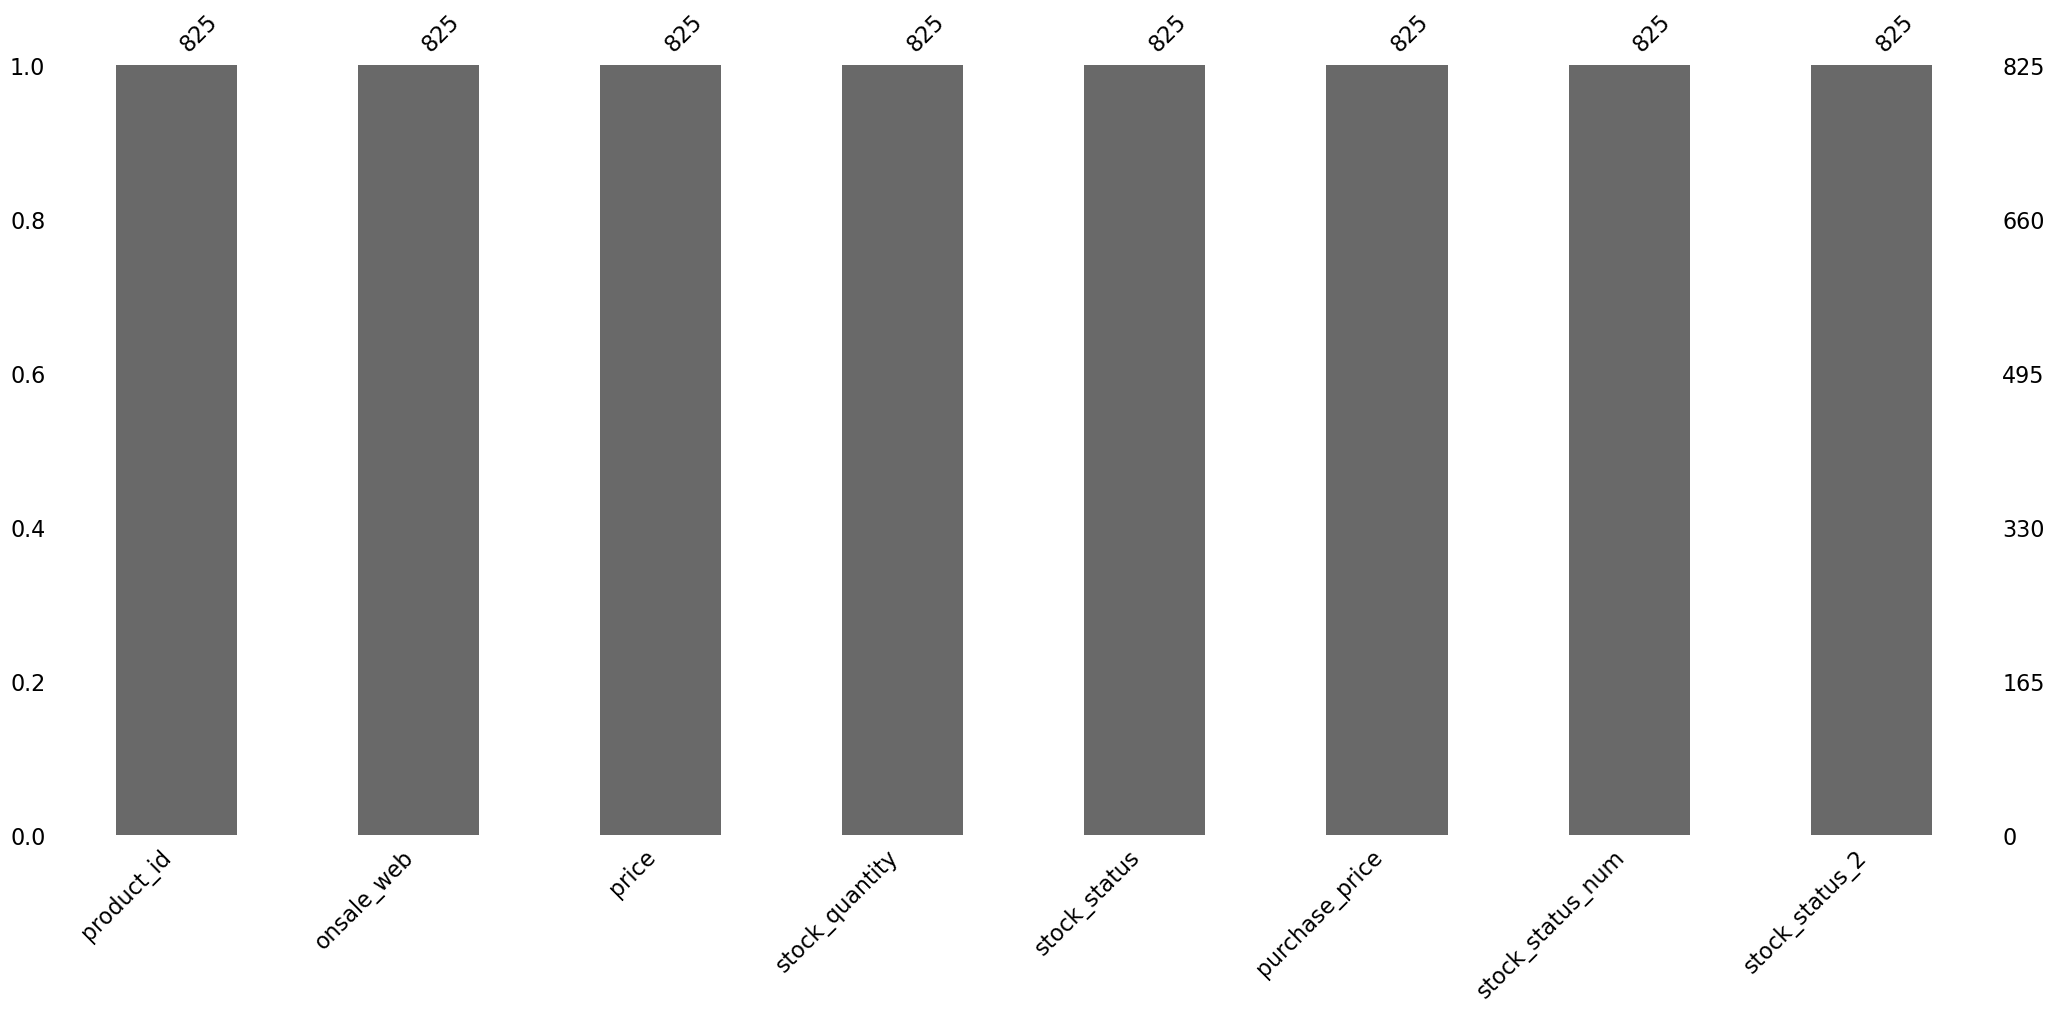

In [349]:
#Quelles sont les colonnes à conserver selon vous?
##toutes sauf df_erp['stock_status_2'] car identique a df_erp['stock_status']
msno.bar(df_erp)
##d'autant plus que, dans les autres colonnes il n'y a aucune donnée manquante dans chacune d'elle:

In [350]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".
df_erp.drop(columns='stock_status_2', inplace=True)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [351]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print('Prix d achats non renseignés:{}'.format(df_erp['purchase_price'].isna().sum()))
#Afficher le prix minimum de la colonne "purchase_price"
print('Prix d achat minimum:{}'.format(df_erp['purchase_price'].min()))
#Afficher le prix maximum de la colonne "purchase_price"
print('Prix d achat maximum:{}'.format(df_erp['purchase_price'].max()))


Prix d achats non renseignés:0
Prix d achat minimum:2.74
Prix d achat maximum:137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [352]:
#Dimension du dataset
print('Dimension du dataset:', df_web.shape)
#Nombre d'observations
print('Nombre d observations (enregistrements):',df_web.shape[0])
#Nombre de caractéristiques
print('Nombre de caractéristiques (variables):',df_web.shape[1])

Dimension du dataset: (1513, 29)
Nombre d observations (enregistrements): 1513
Nombre de caractéristiques (variables): 29


In [353]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

<Axes: >

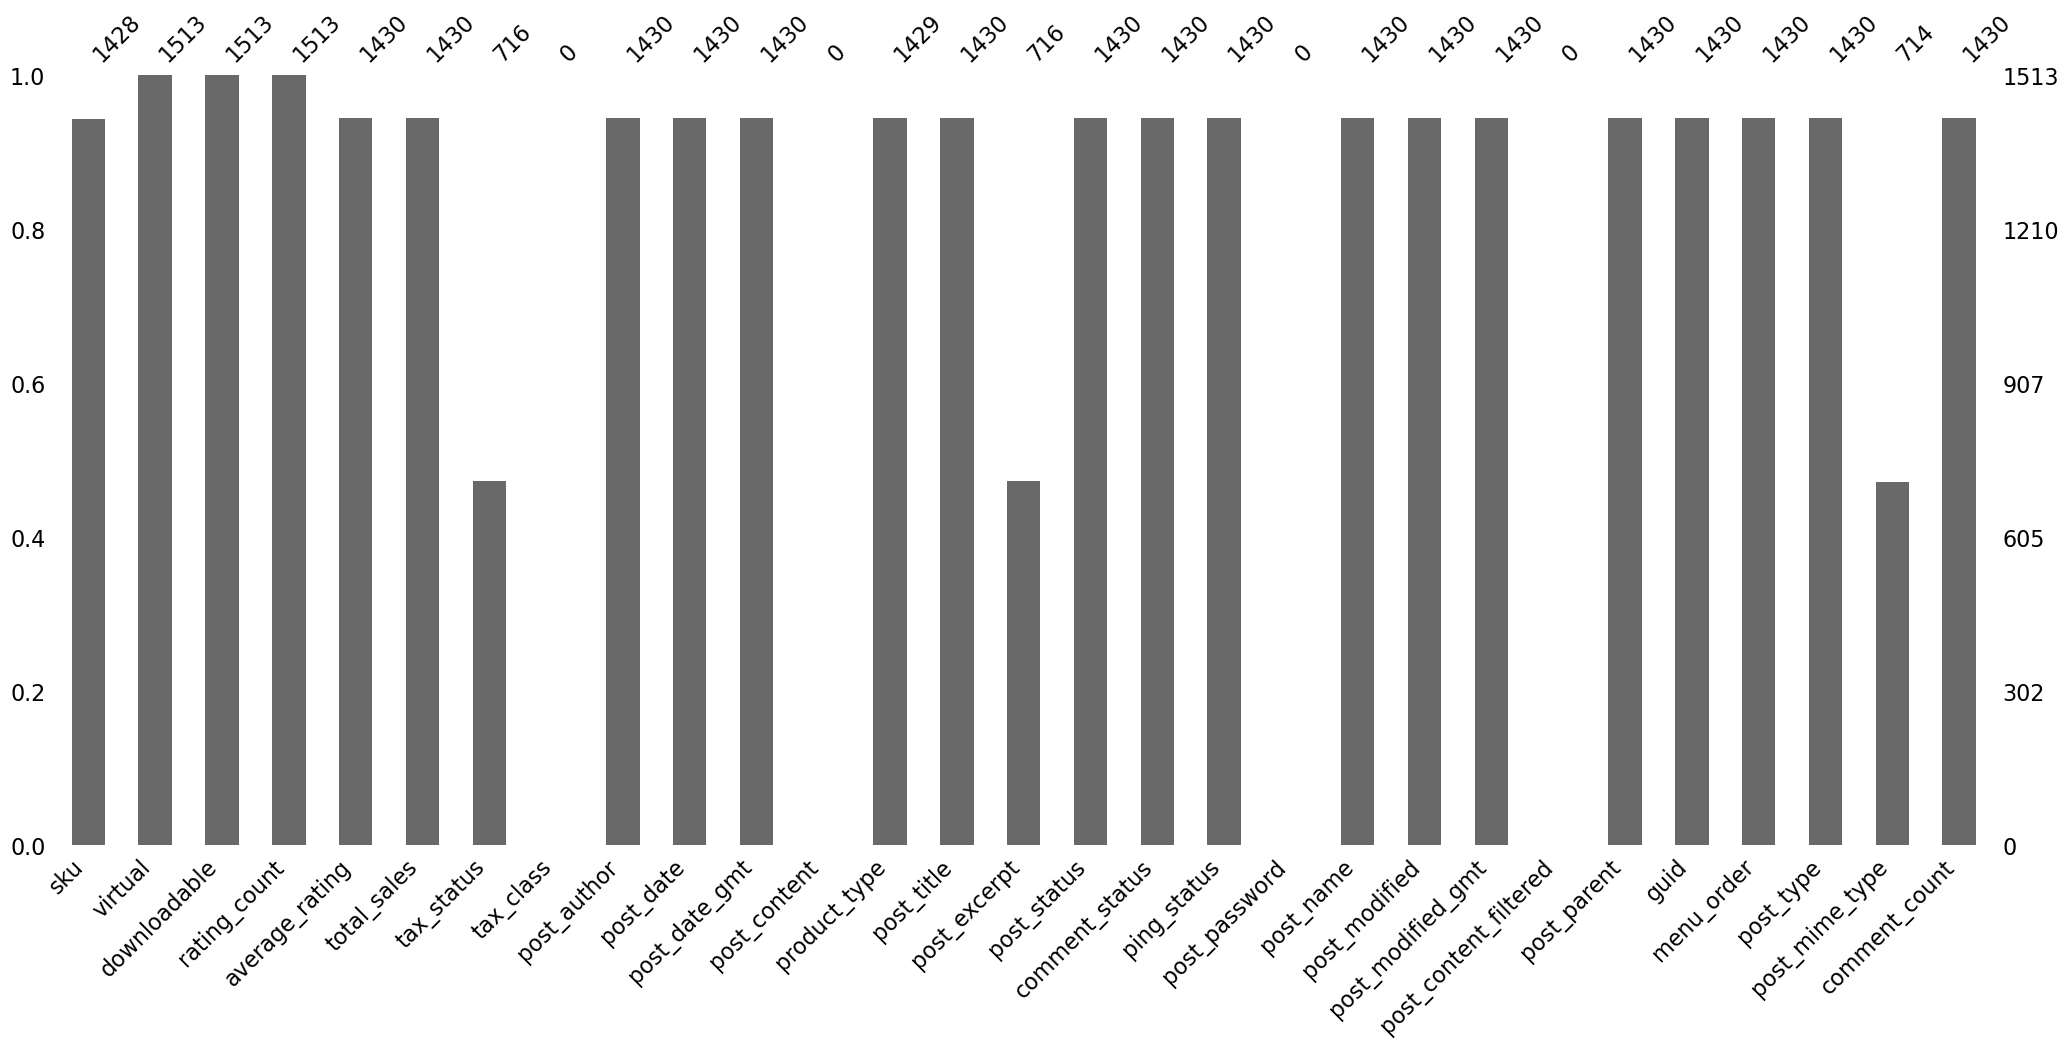

In [354]:
#Selon vous, quelles sont les colonnes à conserver ?
msno.bar(df_web)
##dans un premier temps je supprimerais les colonnes ou il n'y a que des données manquantes cad: ['tax_class'], ['post_content'],['post_password'] et ['post_content_filtered']
##ensuite je supprimerais les colonnes ou il y a plus de 50% des données qui sont manquantes cad:['post_excerpt'],['post_mime_type']
##enfin je ne conserverais que les colonnes qui ont un rapport DIRECT AVEC LA VENTE cad: ['sku'],['total_sales'],['tax_status'],['post_date'],['product_type'],['post_title']

In [355]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
colonnes_a_cons = [
    "sku", "total_sales", "tax_status",
    "post_date", "product_type", "post_title",
    "post_name", "post_modified"
]
df_web= df_web[colonnes_a_cons]

In [356]:
#Visualisation des valeurs de la colonne sku
print(df_web['sku'])
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
##df_web['sku'] est de type object donc il doit y avoir des caracteres dans certains enregistrements 
## confirmé en regardant les filtres dans Excel

0       11862
1       16057
2       14692
3       16295
4       15328
        ...  
1508    16326
1509    15662
1510    15329
1511    14827
1512    16004
Name: sku, Length: 1513, dtype: object


In [357]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
sku_nonnumeriques = df_web[df_web['sku'].str.contains(r'[a-zA-Z\-]', na=False)]
display(sku_nonnumeriques)

,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified
272,13127-1,4.0,taxable,2020-06-09 15:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06
842,bon-cadeau-25-euros,7.0,NaN,2018-06-01 13:53:46,Autre,Bon cadeau de 25€,bon-cadeau-de-25-euros,2018-06-01 14:13:57
1117,13127-1,4.0,NaN,2020-06-09 15:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06
1387,bon-cadeau-25-euros,7.0,taxable,2018-06-01 13:53:46,NaN,Bon cadeau de 25€,bon-cadeau-de-25-euros,2018-06-01 14:13:57


In [358]:
#Identifier les lignes sans code article
lignes_sans_sku = df_web[df_web['sku'].isna()]
print(lignes_sans_sku[['sku']])

      sku
8     NaN
20    NaN
30    NaN
37    NaN
41    NaN
...   ...
1384  NaN
1429  NaN
1432  NaN
1445  NaN
1457  NaN

[85 rows x 1 columns]


In [359]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
print(f'Il y a {len(lignes_sans_sku)} enregistrements ou les identifiants (sku) sont manquants dans le df_web')
##quand j'affiche le df lignes_sans_sku je ne vois que des Nan, ma premiere idée serait de les supprimer car inutiles a l'analyse

Il y a 85 enregistrements ou les identifiants (sku) sont manquants dans le df_web


In [360]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
print(f"Il y a {df_web['sku'].nunique()} doublons dans sku du df_web")

Il y a 714 doublons dans sku du df_web


In [361]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
print(lignes_sans_sku)
#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
lignes_sans_sku.info()
#3 - Que constatez-vous?
##je constate qu'il y a 2 enregistrements ou il y a des valeurs dans les autres colonnes que le sku
##donc je les affiche: 
print(lignes_sans_sku[
      lignes_sans_sku['total_sales'].notna()  & 
      (lignes_sans_sku['total_sales']!= 0)
      ])

      sku  total_sales tax_status post_date product_type post_title post_name  \
8     NaN          NaN        NaN       NaT          NaN        NaN       NaN   
20    NaN          NaN        NaN       NaT          NaN        NaN       NaN   
30    NaN          NaN        NaN       NaT          NaN        NaN       NaN   
37    NaN          NaN        NaN       NaT          NaN        NaN       NaN   
41    NaN          NaN        NaN       NaT          NaN        NaN       NaN   
...   ...          ...        ...       ...          ...        ...       ...   
1384  NaN          NaN        NaN       NaT          NaN        NaN       NaN   
1429  NaN          NaN        NaN       NaT          NaN        NaN       NaN   
1432  NaN          NaN        NaN       NaT          NaN        NaN       NaN   
1445  NaN          NaN        NaN       NaT          NaN        NaN       NaN   
1457  NaN          NaN        NaN       NaT          NaN        NaN       NaN   

     post_modified  
8     

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [362]:
#Dimension du dataset
print(f'Le dataset liaison a pour dimensions {df_liaison.shape}.')
#Nombre d'observations
print(f'Il a {df_liaison.shape[0]} observations (lignes).')
#Nombre de caractéristiques
print(f'Il a {df_liaison.shape[1]} caractéristiques (colonnes).')

Le dataset liaison a pour dimensions (825, 2).
Il a 825 observations (lignes).
Il a 2 caractéristiques (colonnes).


In [363]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [364]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
print(f"Il y a {df_liaison['product_id'].duplicated().sum()} doublons dans la colonne 'product_id', donc les valeurs sont toutes uniques")

Il y a 0 doublons dans la colonne 'product_id', donc les valeurs sont toutes uniques


In [365]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
print(f"Il y a {df_liaison['id_web'].duplicated().sum()} doublons dans la colonne 'id_web', donc les valeurs ne sont pas toutes uniques")

Il y a 90 doublons dans la colonne 'id_web', donc les valeurs ne sont pas toutes uniques


In [366]:
#Avons-nous des articles sans correspondance?
articles_sans_corres= df_liaison[df_liaison['id_web'].isna()]
print(articles_sans_corres)

    id_web  product_id
19     NaN        4055
49     NaN        4090
50     NaN        4092
119    NaN        4195
131    NaN        4209
..     ...         ...
817    NaN        7196
818    NaN        7200
819    NaN        7201
820    NaN        7203
821    NaN        7204

[91 rows x 2 columns]


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [367]:
#Fusion des fichiers df_erp et df_liaison
df_merge= df_erp.merge(df_liaison, how='left',on='product_id', indicator='Merge')
##choix d'une jointure a gauche car df_erp contient tous les produits avec stocks, prix et statut
##aussi car même sans correspondance web, ces produits sont utiles pour l'analyse a venir

In [368]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
df_merge['Merge'].value_counts()
##non, elles correspondent toutes

Merge
both          825
left_only       0
right_only      0
Name: count, dtype: int64

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [369]:
#Fusionner les datasets df_merge et df_web
##tout d'abord je déduplique les valeurs de df_web['sku'], car précédemment j'ai vu qu'elle avait 714 doublons
df_web_unique = df_web.drop_duplicates(subset='sku', keep='first')
df_final= df_merge.merge(df_web_unique, how='left', left_on='id_web', right_on='sku', indicator='merge_')
##j'ai choisi une jointure a gauche pour conserver tous les produits ERP de l'entreprise qui vont m'être utiles pour l'analyse
## de plus certains produits web peuvent ne pas être présents dans l'ERP et inversement

In [370]:
#Avons-nous des lignes sans correspondance?
print(df_final['merge_'].value_counts())
df_final[df_final['merge_'] == 'left_only']
##ces 20 produits ERP ne sont pas disponible sur le site web

merge_
both          805
left_only      20
right_only      0
Name: count, dtype: int64


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_num,id_web,Merge,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified,merge_
193,4289,0,22.8,0,outofstock,11.90,0,13771,both,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,left_only
236,4568,0,21.5,0,outofstock,11.22,0,15065,both,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,left_only
241,4584,0,32.3,0,outofstock,17.36,0,14785,both,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,left_only
355,4741,0,12.4,0,outofstock,6.66,0,12601,both,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,left_only
391,4864,0,8.3,0,outofstock,9.99,0,15154,both,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,left_only
394,4869,0,17.2,0,outofstock,9.33,0,14360,both,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,left_only
424,4921,0,13.8,0,outofstock,7.13,0,15608,both,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,left_only
425,4922,0,21.5,0,outofstock,10.55,0,15586,both,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,left_only
470,5018,0,15.4,0,outofstock,7.72,0,15272,both,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,left_only
473,5021,0,17.1,0,outofstock,8.92,0,15630,both,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,left_only


In [371]:
##df_final.to_excel("df_final.xlsx", index=False)

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

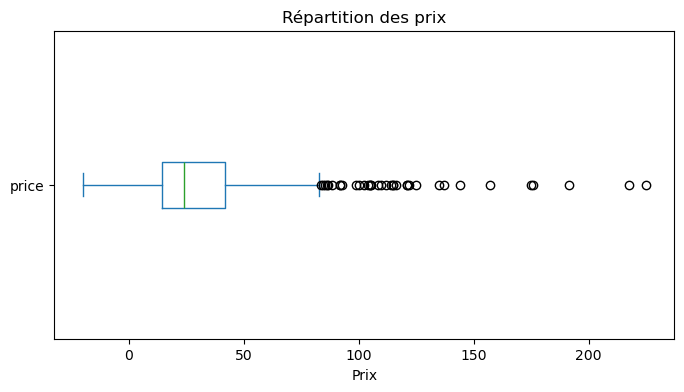

In [372]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_final['price'].plot(kind='box', figsize=(8, 4), vert=False)

plt.title("Répartition des prix")
plt.xlabel("Prix")
plt.show()

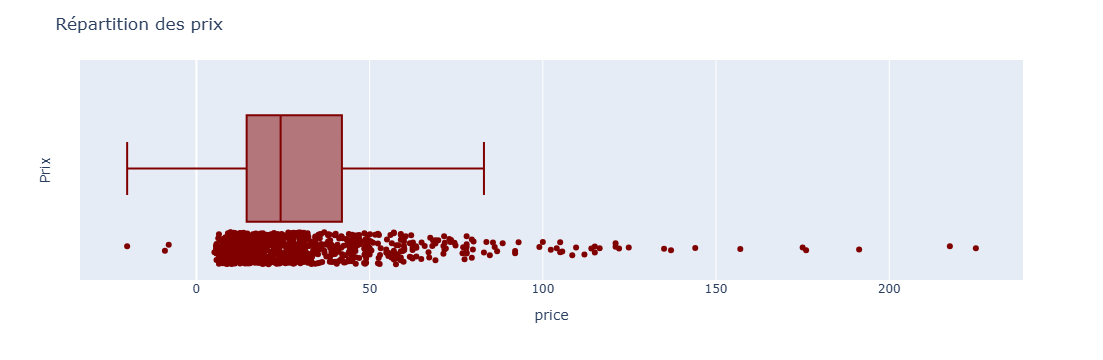

In [373]:
#Autre méthode avec plotly express
fig = px.box(df_final, x="price", points="all", color_discrete_sequence=["#800000"])  
fig.update_layout(
    title="Répartition des prix",
    yaxis_title="Prix"
)
fig.show()


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [374]:
##comme vu précédemment, mais aussi dans la boxplot il y a 3 produits qui ont des prix négatifs negatifs
##je vais donc les transformer en NaN pour les calculs de la moyenne, l'ecart-type et le z-score
df_final['price'] = df_final['price'].mask(df_final['price'] < 0, np.nan)
#Calculer la moyenne du prix
mean_price= df_final['price'].mean()
print("La moyenne du prix est:",round(mean_price,2))
#Calculer l'écart-type du prix
std_price= df_final['price'].std()
print("L ecart type du prix est:", round(std_price,2)) 
#Calculer le Z-score
df_final['zscore'] = (df_final['price'] - mean_price) / std_price
print(df_final['zscore'].head())

La moyenne du prix est: 32.35
L ecart type du prix est: 26.62
0   -0.306144
1    0.073235
2   -0.433856
3   -0.685523
4    0.512714
Name: zscore, dtype: float64


In [375]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
zs_sup_3= df_final[df_final['zscore'] >= 3 ]
seuil_prix = zs_sup_3['price'].min()
print(f"Le prix minimal dont le Z-score est supérieur à 3 est : {seuil_prix} €")

Le prix minimal dont le Z-score est supérieur à 3 est : 114.0 €


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [376]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_final.describe()

,product_id,onsale_web,price,stock_quantity,purchase_price,stock_status_num,total_sales,post_date,post_modified,zscore
count,825.000000,825.000000,822.000000,825.000000,825.000000,825.000000,714.000000,714,714,8.220000e+02
mean,5162.597576,0.867879,32.350304,21.589091,16.940582,0.888485,8.516807,2018-08-22 03:57:52.950980608,2020-06-20 21:45:25.694678016,-6.915258e-17
min,3847.000000,0.000000,5.200000,-10.000000,2.740000,0.000000,0.000000,2018-02-08 12:58:52,2018-02-20 15:19:23,-1.019827e+00
25%,4348.000000,1.000000,14.600000,7.000000,7.590000,1.000000,5.000000,2018-02-27 20:01:12.500000,2020-06-18 18:32:35,-6.667419e-01
50%,4907.000000,1.000000,24.400000,18.000000,12.710000,1.000000,8.000000,2018-04-19 14:52:10,2020-08-04 09:30:06.500000,-2.986315e-01
75%,5805.000000,1.000000,42.000000,30.000000,22.020000,1.000000,11.000000,2019-01-31 14:35:47,2020-08-25 10:32:32,3.624646e-01
max,7338.000000,1.000000,225.000000,145.000000,137.810000,1.000000,122.000000,2020-07-20 11:00:00,2020-08-27 18:55:03,7.236362e+00
std,902.644635,0.338828,26.622453,21.933807,14.561840,0.314960,8.151639,NaN,NaN,1.000000e+00


In [377]:
#Définir un seuil pour les articles "outliers" en prix
Q1= df_final['price'].quantile(0.25)
Q3= df_final['price'].quantile(0.75)
IQR= Q3-Q1
borne_inf= Q1-1.5*IQR
borne_sup= Q3+1.5*IQR

In [378]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
outliers= df_final[(df_final['price'] < borne_inf) | (df_final['price'] > borne_sup)]
print(outliers)
print(f"Il y a {len(outliers)} articles dans les outliers")
prop_outliers= len(outliers) / df_final['price'].notna().sum()
print(f"proportion outliers:{prop_outliers:.2%}")

     product_id  onsale_web  price  stock_quantity stock_status  \
19         4055           0   86.1               0   outofstock   
66         4115           1  100.0              12      instock   
68         4132           1   88.4               7      instock   
208        4352           1  225.0               0   outofstock   
214        4359           1   85.6             112      instock   
227        4402           1  176.0              11      instock   
228        4404           1  108.5              17      instock   
230        4406           1  157.0              12      instock   
231        4407           1  104.0              14      instock   
240        4582           1  109.6              18      instock   
242        4594           1  144.0               0   outofstock   
410        4903           1  102.3              12      instock   
411        4904           1  137.0               9      instock   
460        5001           1  217.5              18      instoc

In [379]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
##Les outliers sont tous les produits dont les prix sont supérieurs (> strict) a la borne_sup cad 83.1
borne_sup
## je pense que ces produits correspondent a de grands crus ou des millesimes rares, voir ces prix eleves pour des bouteilles ne me derange pas

83.1

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [404]:
##############################
# Calculer le CA du site web #
##############################
#Créer une colonne calculant le CA par article
df_final['CA_par_article']=df_final['price']*df_final['total_sales']

#Calculer la somme de la colonne "ca_par_article"
CA_total = df_final['CA_par_article'].sum()

#Ce résultat correspond au chiffre d'affaire du site web
print(f"Le CA du site web est: {CA_total:.0f} €")

Le CA du site web est: 153748 €


    product_id  onsale_web  price  stock_quantity stock_status  \
0         4150           1   59.0             123      instock   
1         4352           1  225.0               0   outofstock   
2         4726           1   12.7               0   outofstock   
3         5067           1   59.9               3      instock   
4         5379           1   11.1              33      instock   
5         5892           1  191.3              98      instock   
6         4353           1   79.5             127      instock   
7         5826           1   41.2              34      instock   
8         6212           1  115.0              16      instock   
9         5026           1   86.8             101      instock   
10        5008           1  105.0              12      instock   
11        5767           1  175.0              12      instock   
12        6126           1  135.0             138      instock   
13        5025           1  112.0             136      instock   
14        

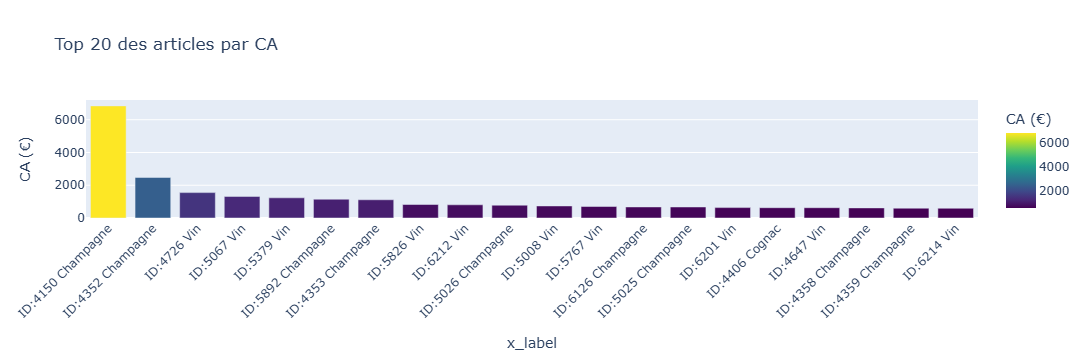

In [407]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
palmares= df_final.sort_values('CA_par_article',ascending=False)
#Réinitialiser l'index du dataset par un reset_index
top_20_CA= palmares.reset_index(drop=True)
#Afficher les 20 premiers articles en CA
top_20_CA= top_20_CA.head(20)
print(top_20_CA)
#Graphique en barre des 20 premiers articles avec plotly express
top_20_CA['x_label'] = " ID:" + top_20_CA['product_id'].astype(str) +" "+ top_20_CA['product_type'].astype(str) 

fig = px.bar(top_20_CA,
            x='x_label',                  
            y='CA_par_article',
            text='CA_par_article',           
            title='Top 20 des articles par CA',
            labels={'CA_par_article': 'CA (€)', 'product_id': 'Produit'},
            color='CA_par_article',
            color_continuous_scale='Viridis',
            hover_data=['product_id']
            )
fig.update_traces(texttemplate='%{text:.2f} €', textposition='outside')
fig.update_layout(xaxis_tickangle=-45, uniformtext_minsize=8, uniformtext_mode='hide')
fig.show()


In [408]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
##je préfère l'afficher directement en pourcentage
df_final['part_CA']= (df_final['CA_par_article']/CA_total) *100

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
##tout d'abord je trie mon df_final['CA_par_article'] par ordre décroissant pour obtenir les BONS 20% des produits qui génèrent 80% du CA
df_final_trie= df_final.sort_values('CA_par_article', ascending=False).reset_index(drop=True)
df_final_trie['cumsum_part_CA']= df_final_trie['part_CA'].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
top_80_CA= df_final_trie[df_final_trie['cumsum_part_CA'] <= 80.00]

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
prop_80_CA= len(top_80_CA)/len(df_final)
print(f" 80% du CA est représenté par {prop_80_CA:.2%} % des articles")

 80% du CA est représenté par 50.91% % des articles


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

C:\Users\julie\AppData\Local\Temp\ipykernel_8648\439850211.py:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



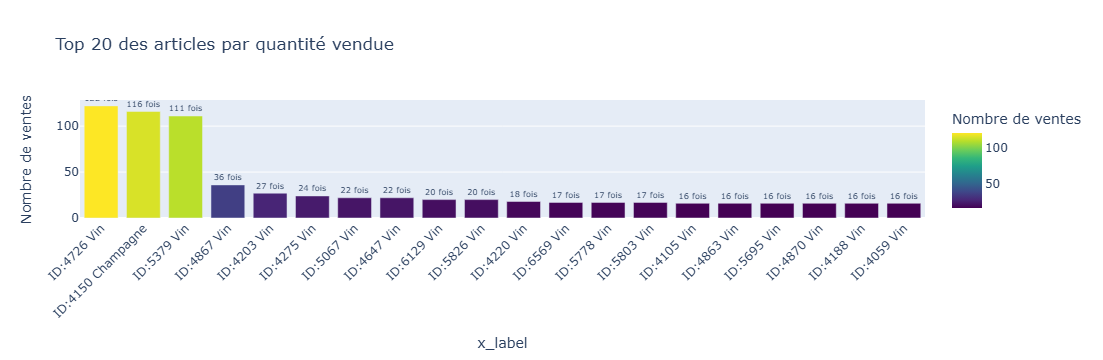

In [383]:
#####################################
# Palmarès des articles en quantité #
#####################################
#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
palmares_qt= df_final.sort_values('total_sales',ascending=False)

#Réinitialiser l'index du dataset par un reset_index
palmares_qt= palmares_qt.reset_index(drop=True)

#Afficher les 20 premiers articles en quantité
top_20_qt= palmares_qt.head(20)

#Graphique en barre des 20 premiers articles avec plotly express
top_20_qt['x_label'] = " ID:" + top_20_qt['product_id'].astype(str) +" "+ top_20_qt['product_type'].astype(str) 

fig = px.bar(top_20_qt,
            x='x_label',                  
            y='total_sales',
            text='total_sales',           
            title='Top 20 des articles par quantité vendue',
            labels={'total_sales': 'Nombre de ventes', 'product_id': 'Produit'},
            color='total_sales',
            color_continuous_scale='Viridis',
            hover_data=['product_id']
            )
fig.update_traces(texttemplate='%{text} fois', textposition='outside')
fig.update_layout(xaxis_tickangle=-45, uniformtext_minsize=8, uniformtext_mode='hide')
fig.show()

In [384]:
#############################
# Calculer le 20 / 80 en CA #
#############################
#Créer une colonne calculant la part en quantité de la ligne dans le dataset
total_qt= df_final['total_sales'].sum()
df_final['part_qt']= (df_final['total_sales']/total_qt)*100

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_final_sorted_qt= df_final.sort_values('total_sales', ascending=False).reset_index(drop=True)
df_final_sorted_qt['cumsum_part_qt']= df_final['part_qt'].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
top_80_qt= df_final_sorted_qt[df_final_sorted_qt['cumsum_part_qt'] <= 80.00]

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
prop_80_qt= len(top_80_qt)/len(df_final)
print(f"80% des ventes en quantité sont représentées par {prop_80_qt:.2%} des produits")

80% des ventes en quantité sont représentées par 66.67% des produits


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

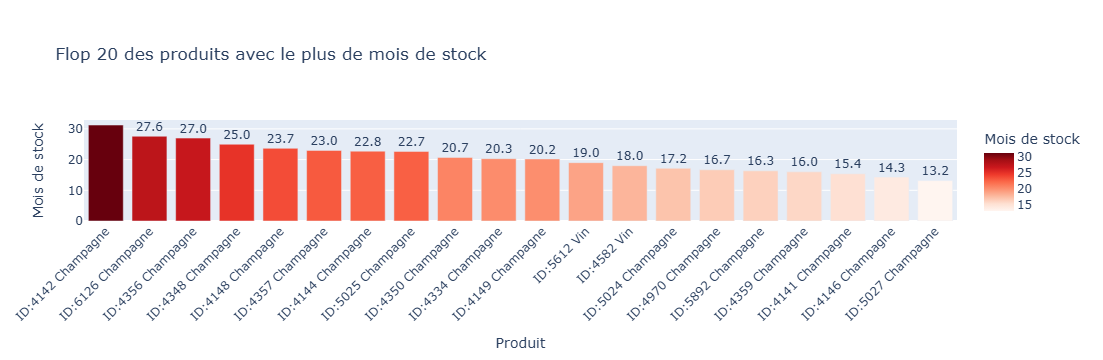

In [385]:
######################################
# Calculer le nombre de mois de stock #
######################################
#Import de numpy 
##deja fait 

#Création de la colonne Rotation de stock
df_final['rotation_stock']= df_final['stock_quantity'] / df_final['total_sales']
##car ventes de 1 mois, du 01/10 au 31/10

#Remplacement des "inf" par 0
##division par 0 pour les 3 product_id: 4337, 4355 et 5932 
df_final['rotation_stock'] = df_final['rotation_stock'].replace([np.inf, -np.inf], 0).fillna(0)

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
flop_20_stock = df_final.sort_values('rotation_stock', ascending=False).head(20)

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
flop_20_stock['x_label'] = "ID:" + flop_20_stock['product_id'].astype(str)  +' '+ flop_20_stock['product_type'].astype(str) 
fig = px.bar(
    flop_20_stock,
    x='x_label',
    y='rotation_stock',
    text='rotation_stock',
    title='Flop 20 des produits avec le plus de mois de stock',
    labels={'rotation_stock': 'Mois de stock', 'x_label': 'Produit'},
    color='rotation_stock',
    color_continuous_scale='Reds',
    hover_data=['product_id', 'stock_quantity', 'total_sales']
)
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig.update_layout(xaxis_tickangle=-45, margin=dict(t=120))
fig.show()

C:\Users\julie\AppData\Local\Temp\ipykernel_8648\1881824814.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




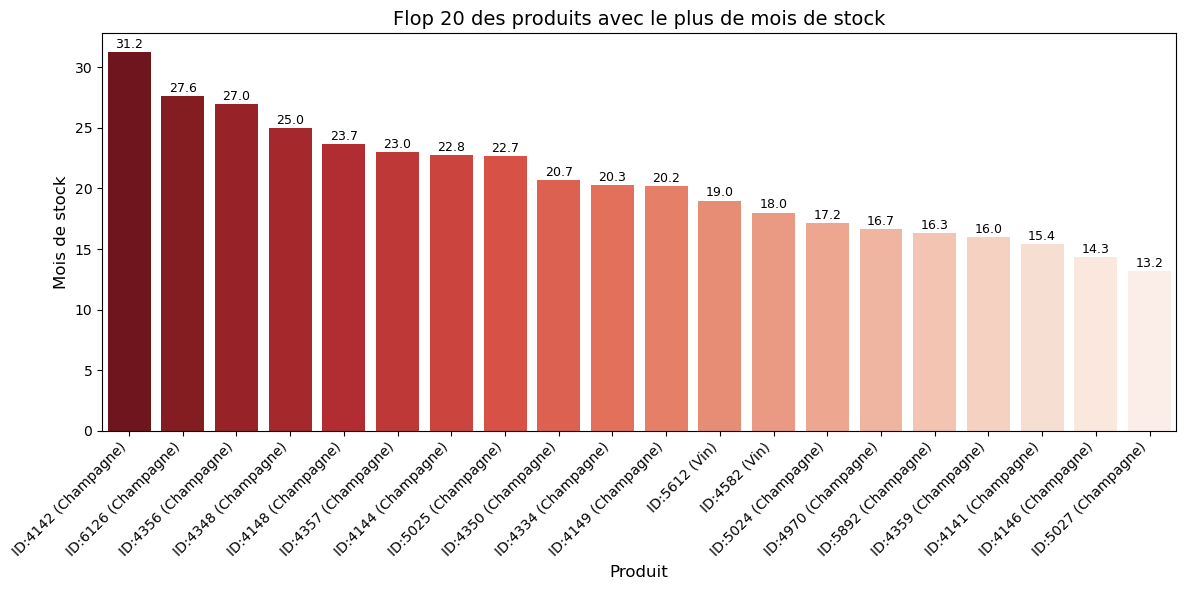

In [386]:
##OPTION SANS PLOTLY EXPRESS##
flop_20_stock['x_label'] = "ID:" + flop_20_stock['product_id'].astype(str) + " (" + flop_20_stock['product_type'].astype(str) + ")"

plt.figure(figsize=(12,6))
sns.barplot(
    data=flop_20_stock,
    x='x_label',
    y='rotation_stock',
    palette="Reds_r"  
)
for index, value in enumerate(flop_20_stock['rotation_stock']):
    plt.text(index, value + 0.1, round(value, 1), ha='center', va='bottom', fontsize=9)
plt.title("Flop 20 des produits avec le plus de mois de stock", fontsize=14)
plt.xlabel("Produit", fontsize=12)
plt.ylabel("Mois de stock", fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("flop_20_stock.png", dpi=300)
plt.show()

In [387]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_final['valo_stocks_euros']= df_final['stock_quantity']*df_final['purchase_price']

#Calculer la somme de la colonne "Valorisation_stock_euros"
valo_totale = df_final['valo_stocks_euros'].sum()
print(f"La valorisation totale du stock est de {valo_totale:,.2f} €")

La valorisation totale du stock est de 298,555.76 €


In [388]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
stock_quantity_totale= df_final['stock_quantity'].sum()
print(f"Au total, le stock est composé de {stock_quantity_totale} articles.")

Au total, le stock est composé de 17811 articles.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [389]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
##la TVA pour chacun des produits vendus:df_final['product_type'].unique() 
##array(['Vin', nan, 'Champagne', 'Whisky', 'Cognac', 'Autre',"Huile d'olive", 'Gin'], dtype=object), est de 20% 
##donc je divise par 1.20 pour enlever la TVA 
df_final['Prix_HT'] = df_final['price'] / 1.20  

#Création de la colonne Taux de marge
df_final['taux_marge'] = (df_final['Prix_HT'] - df_final['purchase_price']) / df_final['Prix_HT']

#Afficher le prix minimum de la colonne "taux_marge"
print("Taux de marge minimum :", df_final['taux_marge'].min())

#Afficher le prix maximum de la colonne "taux_marge"
print("Taux de marge maximum :", df_final['taux_marge'].max())

Taux de marge minimum : -6.3498814229249
Taux de marge maximum : 0.477568


In [390]:
#Affichage de la ligne avec un taux de marge inférieur à 0
print(df_final[df_final['taux_marge']<0])
##4 produits ont un taux de marge négatif, ce qui correspond à des cas où le prix d’achat est supérieur au prix de vente HT. 
##Il s’agit probablement d’erreurs de saisie à corriger

     product_id  onsale_web  price  stock_quantity stock_status  \
210        4355           1  12.65              97      instock   
391        4864           0   8.30               0   outofstock   
724        6324           0  92.00              18      instock   
817        7196           0  31.00              55      instock   

     purchase_price  stock_status_num id_web Merge    sku  ...  \
210           77.48                 1  12589  both  12589  ...   
391            9.99                 0  15154  both    NaN  ...   
724           99.00                 1    NaN  both    NaN  ...   
817           31.20                 1    NaN  both    NaN  ...   

          post_modified     merge_    zscore CA_par_article part_CA part_qt  \
210 2020-08-13 10:15:02       both -0.739988            0.0     0.0     0.0   
391                 NaT  left_only -0.903384            NaN     NaN     NaN   
724                 NaT       both  2.240578            NaN     NaN     NaN   
817              

In [391]:
#Création d'un dataframe avec les taux positifs
df_marge_positive = df_final[df_final['taux_marge'] >= 0]

#Afficher le prix minimum de la colonne "taux_marge"
print("Taux de marge minimum :", df_marge_positive['taux_marge'].min())

#Afficher le prix maximum de la colonne "taux_marge"
print("Taux de marge maximum :", df_marge_positive['taux_marge'].max())

Taux de marge minimum : 0.22778625954198473
Taux de marge maximum : 0.477568


C:\Users\julie\AppData\Local\Temp\ipykernel_8648\1862358585.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\julie\AppData\Local\Temp\ipykernel_8648\1862358585.py:10: UserWarning:

Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14



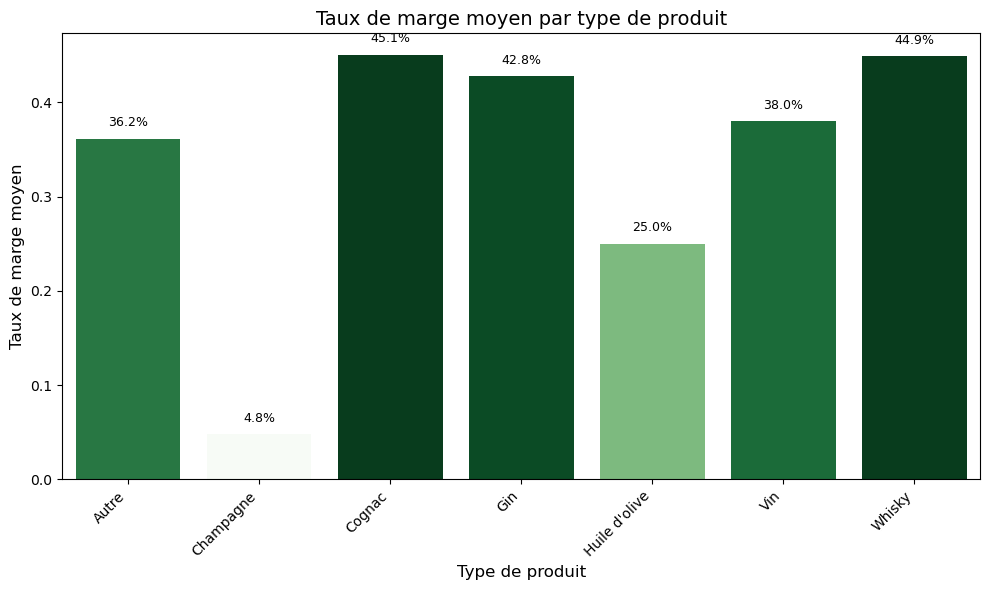

In [392]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
marge_par_type = df_final.groupby('product_type')['taux_marge'].mean().reset_index()

#Affichage dans un graphique du taux de marge par type de produit

norm = mcolors.Normalize(vmin=marge_par_type['taux_marge'].min(), vmax=marge_par_type['taux_marge'].max())
colors = cm.Greens(norm(marge_par_type['taux_marge'].values))

plt.figure(figsize=(10,6))
sns.barplot(
    data=marge_par_type,
    x='product_type',
    y='taux_marge',
    palette=colors  
)

for index, value in enumerate(marge_par_type['taux_marge']):
    plt.text(index, value + 0.01, f"{value*100:.1f}%", ha='center', va='bottom', fontsize=9)
    
plt.title("Taux de marge moyen par type de produit", fontsize=14)
plt.xlabel("Type de produit", fontsize=12)
plt.ylabel("Taux de marge moyen", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("marge_par_type.png", dpi=300)
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

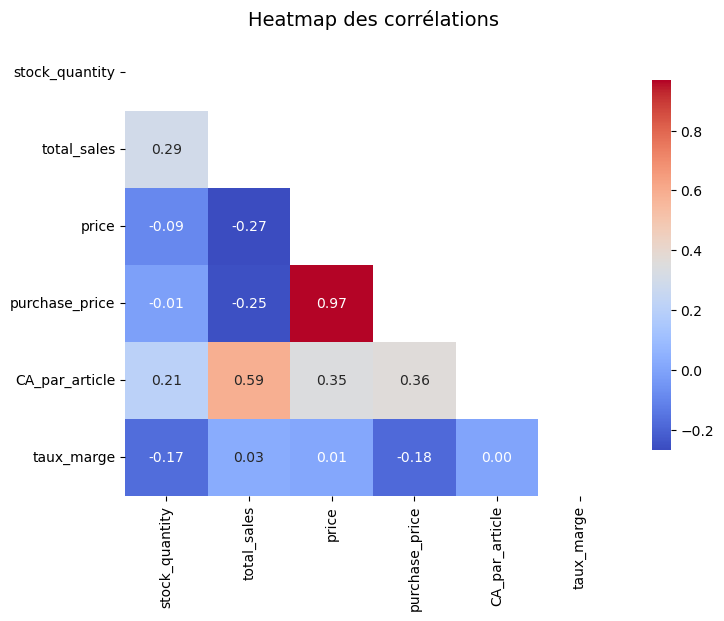

In [393]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn
##deja fait au début

#Création d'une heatmap de corrélation avec les variables stock, sales et price
#On peut également créer un mask pour n'afficher qu'une demi heatmap
cols_corr = ['stock_quantity', 'total_sales', 'price', 'purchase_price', 'CA_par_article', 'taux_marge']
corr_matrix = df_final[cols_corr].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,          
    fmt=".2f",           
    cmap="coolwarm",     
    cbar_kws={"shrink": .8}  
)
plt.title("Heatmap des corrélations", fontsize=14)
plt.savefig("heatmap_correlations.png", dpi=300, bbox_inches='tight')
plt.show()

In [394]:
#Que peut-on conclure des corrélations ?
"""
-entre purchase_price et price: correlation tres positive : 0.97 le prix de vente augmente proportionnellement au prix d’achat 
(les marges suivent souvent les coûts, donc ajuster le prix d’achat impacte directement le CA et la marge)
_entre CA_par_article et total_sales: corrélation positive modérée à forte: 0.59 plus un article se vend en grande quantité (total_sales élevé), plus son chiffre d’affaires par article (CA_par_article) 
tend à être élevé. Le volume de ventes joue un rôle important dans le CA, mais ce n’est pas le seul facteur déterminant 
(le prix unitaire et la marge viennent nuancer la relation)
le prix unitaire et la marge viennent nuancer la relation.
-entre total_sales et stock_quantity: corrélation faible à modérée: 0.29: avoir plus de stock ne garantit pas des ventes plus élevées, mais il y a
quand même une légère tendance positive (certains produits se vendent bien même avec peu de stock, d’autres stagnent malgré de gros stocks donc 
une gestion optimisée est nécessaire)
-entre CA_par_article et stock_quantity: corrélation faible a modérée:0.21 : un stock plus important permet un CA plus élevé car il y a plus de produits 
disponibles à la vente (montre que la gestion des stocks impacte directement le CA)
-entre CA_par_article et price: corrélation modérée: 0.35
 et CA_par_article et purchase_price: corrélation modérée: 0.36 on voit que prix et quantité vendue combinés déterminent le CA
-le reste: corrélations très faibles proches de 0: pas de lien linéaire notable (ces variables n’ont pas d’effet direct et peuvent être étudiées 
séparément si nécessaire)
"""

'\n-entre purchase_price et price: correlation tres positive : 0.97 le prix de vente augmente proportionnellement au prix d’achat \n(les marges suivent souvent les coûts, donc ajuster le prix d’achat impacte directement le CA et la marge)\n-entre total_sales et stock_quantity: corrélation faible à modérée: 0.29: avoir plus de stock ne garantit pas des ventes plus élevées, mais il y a\nquand même une légère tendance positive (certains produits se vendent bien même avec peu de stock, d’autres stagnent malgré de gros stocks donc \nune gestion optimisée est nécessaire)\n-entre CA_par_article et stock_quantity: corrélation forte:0.71 : un stock plus important permet un CA plus élevé car il y a plus de produits \ndisponibles à la vente (montre que la gestion des stocks impacte directement le CA)\n-entre CA_par_article et price: corrélation modérée: 0.40\n et CA_par_article et purchase_price: corrélation modérée: 0.45 on voit que prix et quantité vendue combinés déterminent le CA\n-le reste: 

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [395]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.  
df_final.to_excel("df_final_export.xlsx", index=False)